## Regressão kNN com o uso de PCA e Clusters

## Autores

| Nome | nUSP |
| :--- | :--- |
| Débora da Silva Morais     | 15615790 |
| Guilherme de Abreu Barreto | 12543033 |

## Introdução

Na presente análise retomamos o artigo [Supervised Machine Learning for Estimation of Total Suspended Solids in Urban Watersheds](https://www.mdpi.com/2073-4441/13/2/147) e buscamos aprimorar as predições obtidas em análise anterior para a técnica de Regressão kNearestNeighbors ao complementá-la com:

- Redução de dimensionalidade usando Análise de Componentes Principais (_Principal Component Analysis_).
- Remoção de outliers com distância de Malahanobis.
- Alteração da métrica de desempenho utilizada.

Retomando os resultados obtidos na [análise anterior](https://github.com/de-abreu/machine-learning/blob/main/02%20-%20Regress%C3%A3o%20kNN/Regress%C3%A3o%20com%20kNN.ipynb), tivemos que o experimento não era reprodutível guiando-se apenas pelos hiperparâmetros descritos, pelo menos ao não fazermos uso da ferramenta [Orange](https://orangedatamining.com/). Não apenas isto, mas os resultados obtidos tiveram desempenho muito inferior ao relatado no artigo. À saber, para a regressão linear kNN com o uso de pesos baseados na distância entre os pontos:

| Parâmetro | Artigo | Reprodução |
| :--- | :--- | :--- |
| K ótimo | 45 | 10 |
| R² | 0.56 | -0.181 |
| RMSE | 170 mg/L | 117.91 mg/L |
| NSE | 0.55 | - 0.181 |

Temos como hipótese que o desempenho preditivo da técnica kNN é negativamente afetado na presença de amostras em situações cuja comparação é indevida. Ao identificarmos amostras em agrupamentos e aplciarmos a técnica kNN sobre estes agrupamentos separadamente, o desempenho geral deve apresentar melhora.

## Carregamento de Dependências e fixaçãodo seed para geração de valores pseudo-aleatórios

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from plotly.graph_objects import Figure, Scatter3d, Cone
from math import ceil
from sklearn.cluster import KMeans
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import GridSearchCV, cross_val_predict, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.decomposition import PCA
from sklearn.metrics import (
    r2_score as R2,
    silhouette_score,
    root_mean_squared_error as RMSE,
    confusion_matrix,
    median_absolute_error as MedAE
)
from sklearn.pipeline import Pipeline
from sklearn.covariance import MinCovDet
from matplotlib.lines import Line2D
from typing import Any

In [2]:
SEED = 42
np.random.seed(SEED)

## Carregamento dos dados

In [3]:
dataset = {
    'filepath_or_buffer': '../NSQD_v4.02_2015.csv',
    'sep': '|',
    'encoding': 'latin-1',
}

columns = [
    # Hydrological factors
    'Precipitation_Depth_(in)',
    'Runoff_(in)',
    'Days since last rain',

    # Drainage factors
    'Drainage_Area_Acres',
    'Percent_Impervious',

    # Land use
    'Percentage_Residential',
    'Percentage_Commercial',
    'Percentage_Industrial',
    'Percentage_Open_Space',
    'Percentage_Freeway',

    # Target
    'TSS (mg/L)',

    # Context
    'EPA_Rain_Zone',
    'Season',
]

dtype = {
    'Season': 'object',
    'EPA_Rain_Zone': 'Int64',
}

def float_or_nan(value: Any) -> float | type(np.nan):
    try:
        return float(value)
    except ValueError:
        return np.nan

df = pd.read_csv(
    **dataset,
    usecols=columns,
    dtype=dtype,
    na_values=[''],
    converters={col: float_or_nan for col in columns[:-2]},
    nrows=9051
)

df.dropna(axis='index', inplace=True)
df.rename(
    columns={
        'Precipitation_Depth_(in)': 'Precipitation depth (in)',
        'Runoff_(in)': 'Runoff depth (in)',
        'Drainage_Area_Acres': 'Drainage area (Acres)',
        'Percent_Impervious': 'Imperviousness (%)',
        'Percentage_Residential': 'Residential (%)',
        'Percentage_Institutional': 'Institutional (%)',
        'Percentage_Commercial': 'Commercial (%)',
        'Percentage_Industrial': 'Industrial (%)',
        'Percentage_Open_Space': 'Open Space (%)',
        'Percentage_Freeway': 'Freeway (%)',
        'Percentage_Water': 'Water (%)',
        'EPA_Rain_Zone': 'EPA rain zone',
        'Main_Type_Conveyance': 'Main conveyance',
    },
    inplace=True
)

INCH_TO_MM = 25.4
ACRE_TO_M2 = 4046.86

df['Drainage area (km²)'] = (
    df['Drainage area (Acres)'] * ACRE_TO_M2 * 10**3
)
df['Precipitation depth (mm)'] = (
    df['Precipitation depth (in)'] * INCH_TO_MM
)
df['Runoff volume (m³)'] = (
    df['Runoff depth (in)'] * INCH_TO_MM * 10**3
    * df['Drainage area (Acres)'] * ACRE_TO_M2
)

df['Stratification Group'] = (
    df['EPA rain zone'].astype(str) + '_' + df['Season'].astype(str)
)

df.drop(
    columns=[
        'Drainage area (Acres)',
        'Precipitation depth (in)',
        'Runoff depth (in)',
        'EPA rain zone',
        'Season',
    ],
    inplace=True
)

features = [
    'Precipitation depth (mm)',
    'Runoff volume (m³)',
    'Drainage area (km²)',
    'Imperviousness (%)',
    'Residential (%)',
    'Commercial (%)',
    'Industrial (%)',
    'Open Space (%)',
    'Freeway (%)',
    'Days since last rain',
]

target = 'TSS (mg/L)'
df.describe()

,Residential (%),Commercial (%),Industrial (%),Open Space (%),Freeway (%),Imperviousness (%),Days since last rain,TSS (mg/L),Drainage area (km²),Precipitation depth (mm),Runoff volume (m³)
count,562.000000,562.000000,562.000000,562.000000,562.000000,562.000000,562.000000,562.000000,5.620000e+02,562.000000,5.620000e+02
mean,27.745018,23.264591,19.720996,8.888434,17.072776,56.365480,11.621343,166.229644,2.190181e+08,17.028124,1.208469e+09
std,41.170640,37.334133,35.969579,19.481193,35.499085,25.250445,22.782389,257.304289,2.628925e+08,12.726055,1.748703e+09
min,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.500000,3.000000,1.618744e+06,0.762000,1.017623e+06
25%,0.000000,0.000000,0.000000,0.000000,0.000000,36.000000,3.120417,39.250000,7.203411e+07,7.874000,1.438395e+08
50%,0.000000,0.000000,0.000000,0.000000,0.000000,60.000000,6.000000,73.500000,1.659213e+08,13.462000,4.961377e+08
75%,80.000000,39.900000,10.800000,7.000000,1.000000,79.300000,12.000000,166.750000,2.642600e+08,22.352000,1.514655e+09
max,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,290.000000,2325.000000,4.532483e+09,99.060000,1.299980e+10


## Normalização dos valores e Visualização dos componentes principais

In [4]:
scaled_features = StandardScaler().fit_transform(df[features])
pca = PCA(n_components=scaled_features.shape[1])
pca_scores = pca.fit_transform(scaled_features)

In [5]:
def PCA_Heatmap(features, pca_scores) -> None:
    pca_columns = [f"PC{i+1}" for i in range(pca.n_components_)]
    
    # Create loadings heatmap
    plt.figure(figsize=(10, 6))
    sns.heatmap(
        pd.DataFrame(
            pca.components_.T,  # Transpose to align columns with PCs
            columns=pca_columns,
            index=features
        ),
        annot = True,
        cmap = 'coolwarm',
        center = 0
    )
    plt.title("Loadings (Orientação das colunas originais aos componentes principais)")
    plt.tight_layout()
    plt.show()
    
    # Display variance
    display(
        pd.DataFrame({
            'Componente Principal': pca_columns,
            'Variância explicada (%)': pca.explained_variance_ratio_ * 100,
            'Variância cumulativa (%)': np.cumsum(pca.explained_variance_ratio_) * 100
        })
            .style.hide(axis='index')
            .format({
            'Variância explicada (%)': '{:.2f}',
            'Variância cumulativa (%)': '{:.2f}'
        })
    )

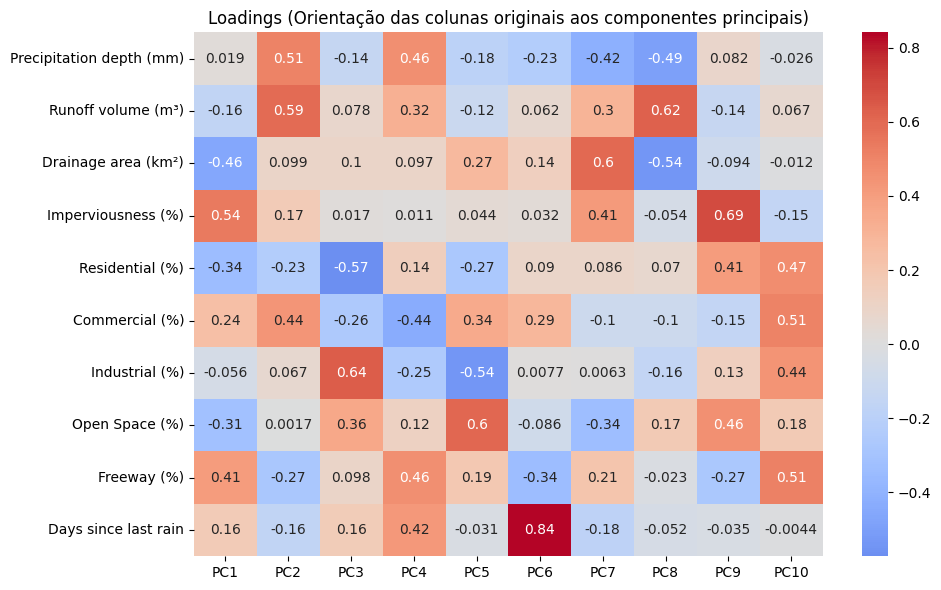

Componente Principal,Variância explicada (%),Variância cumulativa (%)
PC1,24.21,24.21
PC2,16.64,40.85
PC3,13.83,54.68
PC4,11.99,66.66
PC5,11.43,78.09
PC6,8.78,86.87
PC7,6.47,93.34
PC8,3.63,96.97
PC9,2.64,99.62
PC10,0.38,100.00


In [6]:
PCA_Heatmap(features, pca_scores)

## Exibição dos três primeiros componentes principais

In [7]:
def PCA_Scatterplot(features, pca_scores) -> None:
    loadings = pca.components_[:3].T
    fig = Figure()
    
    # Get the first 3 principal components
    pc1, pc2, pc3 = pca_scores[:, 0], pca_scores[:, 1],  pca_scores[:, 2]
    
    # Add data points
    fig.add_trace(
        Scatter3d(
            x = pc1,
            y = pc2,
            z = pc3,
            mode='markers',
            marker= {
                'size': 4,
                'color': df[target],
                'colorscale': "Viridis",
                'opacity': 0.7,
                'colorbar': {'title': 'TSS (mg/L)'},
            },
            text= [f'TSS: {val:.1f} mg/L' for val in df[target]],
            showlegend=False,  # ← Remove from legend
            name=''  # Empty name
        )
    )
    
    # Add loading arrows
    arrow_scale = 2.5
    for i, feature in enumerate(features):
    
        # Add arrow line
        fig.add_trace(
            Scatter3d(
                x = [0, loadings[i, 0] * arrow_scale],
                y = [0, loadings[i, 1] * arrow_scale],
                z = [0, loadings[i, 2] * arrow_scale],
                mode = 'lines',
                showlegend = False,
                hoverinfo = 'none',
            )
        )
    
        # Arrowhead
        fig.add_trace(Scatter3d(
            x=[0, loadings[i, 0] * arrow_scale],
            y=[0, loadings[i, 1] * arrow_scale], 
            z=[0, loadings[i, 2] * arrow_scale],
            mode = 'markers',
            marker = { 'size': 4, 'color': 'red', 'symbol': 'diamond' },
            showlegend = False,
            hoverinfo = 'none'
        ))
    
        # Feature label
        fig.add_trace(Scatter3d(
            x=[loadings[i, 0] * arrow_scale * 1.15],
            y=[loadings[i, 1] * arrow_scale * 1.15],
            z=[loadings[i, 2] * arrow_scale * 1.15],
            mode='text',
            text=[feature],
            textposition='middle center',
            showlegend=False,
            hoverinfo='none'
        ))
    
    fig.update_layout(
        title = 'Gráfico de dispersão 3D com o carregamento dos parâmetros',
        scene = {
            'xaxis_title': 'PC1',
            'yaxis_title': 'PC2',
            'zaxis_title': 'PC3',
            'camera' : { 'eye': {'x': 1.5, 'y': 1.5, 'z': 1.5} } # Initial view angle
        },
        width=800,
        height=600,
        showlegend=False  # ← Completely remove the legend
    )
    
    fig.show()

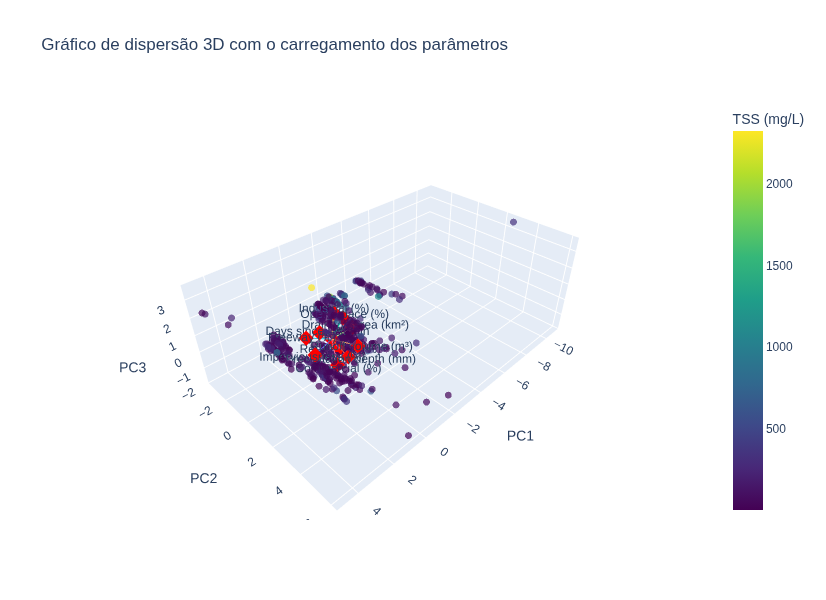

In [8]:
PCA_Scatterplot(features, pca_scores)

## Remoção dos outliers pela distância de Malahanobis

Buscamos tornar nossa remoção de outliers mais robusta ao selecionarmos a amostra para a análise considerando as 530 observações com a menor [distância de Mahalanobis](https://en.wikipedia.org/wiki/Mahalanobis_distance). A distância de Malahanobis trata-se de uma generalização multivariada do Z-score: a distancia $d_M$, em unidades de desvio padrão, que um dado ponto encontra-se da média. A distância sendo 0 quando $P$ encontra-se na média e aumenta de grandeza conforme este se afasta em cada eixo de componente principal. Esta pode ser expressa na fórmula:

$$
d_M(\vec x, Q) = \sqrt{(\vec x - \vec \mu)^T \Sigma^{-1} (\vec x - \vec \mu)}
$$

Sendo:

- $Q$ a distribuição de probabilidades em $R^n$;
- $\vec \mu$ a média $\vec \mu = (\mu_1, \mu_2, \dots, \mu_n)^T$;
- $\Sigma$ a matriz de covariância.

Quando cada um dos eixos é reescalado para possui variância unitária e não possuem correlação, a distância de Mahalanobis corresponte a distância Euclidiana. Este é o nosso caso pois normalizamos os parâmetros de entrada e já claculamos as componentes do PCA (que não possuem covariância entre si).

À seguir, calculamos a distância de Mahalanobis, eliminamos os outliers, e atualizamos os gráficos exibidos anteriormente.

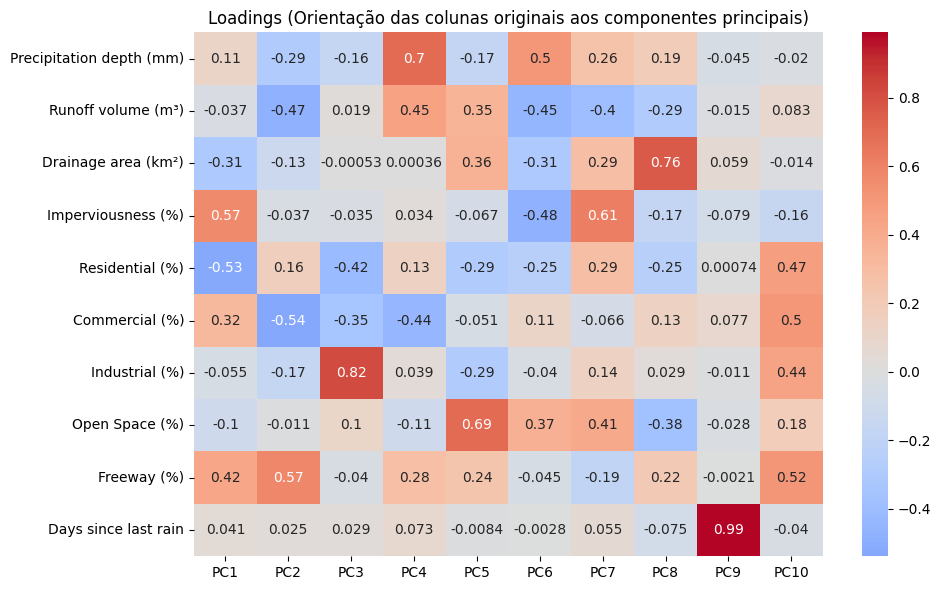

Componente Principal,Variância explicada (%),Variância cumulativa (%)
PC1,27.72,27.72
PC2,18.56,46.28
PC3,17.58,63.86
PC4,13.38,77.24
PC5,7.98,85.22
PC6,6.30,91.52
PC7,3.54,95.07
PC8,2.66,97.72
PC9,1.77,99.49
PC10,0.51,100.00


In [9]:
mcd = MinCovDet(support_fraction=0.75, random_state=SEED)
mcd.fit(pca_scores)

dist = mcd.mahalanobis(pca_scores)
selected_indices = np.argsort(dist)[:530]

filtered_features = scaled_features[selected_indices]
filtered_targets = df[target].iloc[selected_indices]
filtered_pca = pca.fit_transform(filtered_features)
PCA_Heatmap(features, filtered_pca)
PCA_Scatterplot(features, filtered_pca)

# Aplicar kNN sobre as features escaladas

Selecionadas nostras amostras, aplicamos o algoritmo kNN diretamente sobrea totalidade dos valores normalizados dos parâmetros, esta aplicação servirá de _baseline_ de desempenho para o restante de nossa análise, one estes serão reduzidos em dimensionalidade e, no mais, separados em grupos.

In [10]:
def NSE(
    y_actual: list[float],
    y_predicted: list[float],
) -> float:
    """Calculates the Nash-Sutcliffe Efficiency."""
    numerator = np.sum((y_actual - y_predicted) ** 2)
    denominador = np.sum((np.mean(y_actual) - y_actual) ** 2)
    return 1 - (numerator / denominador)


def plot_regression_results(
    gs: GridSearchCV | None, X, y, subtitle: str | None
) -> None:
    if gs is None:
        return
        
    y_pred = cross_val_predict(
        gs.best_estimator_,
        X,
        y,
        cv=5,
    )

    # Create Figure
    plt.figure(figsize=(10,8))
    plt.scatter(y, y_pred, alpha=0.6, s=50)
    plt.grid(True, alpha=0.3)

    # Calcualte maximum value for axis limits
    axis_max = max(y.max(), y_pred.max())

    # 1:1 line (indicative of a perfect prediction)
    plt.plot([0, axis_max], [0, axis_max], 'k--', linewidth=1, label='Linha 1:1')

    # Regression line (average prediction trend)
    lr = LinearRegression()
    lr.fit(y.values.reshape(-1, 1), y_pred)
    x_line = np.linspace(0, axis_max, 100)
    y_line = lr.predict(x_line.reshape(-1, 1))
    plt.plot(x_line, y_line, 'r-', linewidth=2, label="Tendência média")

    # Add title and axis labels
    if subtitle is None:
        plt.title('Previsão vs. Real')
    else:
        plt.title(f'Previsão vs. Real: {subtitle}')
    plt.xlabel('TSS Real (mg/L)')
    plt.ylabel('TSS Previsto (mg/L)')
    
    # Add statistics to the plot
    plt.text(
        0.05,
        0.95,
        f"""
        RMSE: {-gs.best_score_:.2f}
        R²: {R2(y, y_pred):.2f}
        NSE: {NSE(y, y_pred):.2f}
        """,
        transform=plt.gca().transAxes,
        verticalalignment='top',
        bbox= {'boxstyle': 'round', 'facecolor': 'white', 'alpha': 0.8},
    )

    plt.legend()
    plt.tight_layout()
    plt.show()    

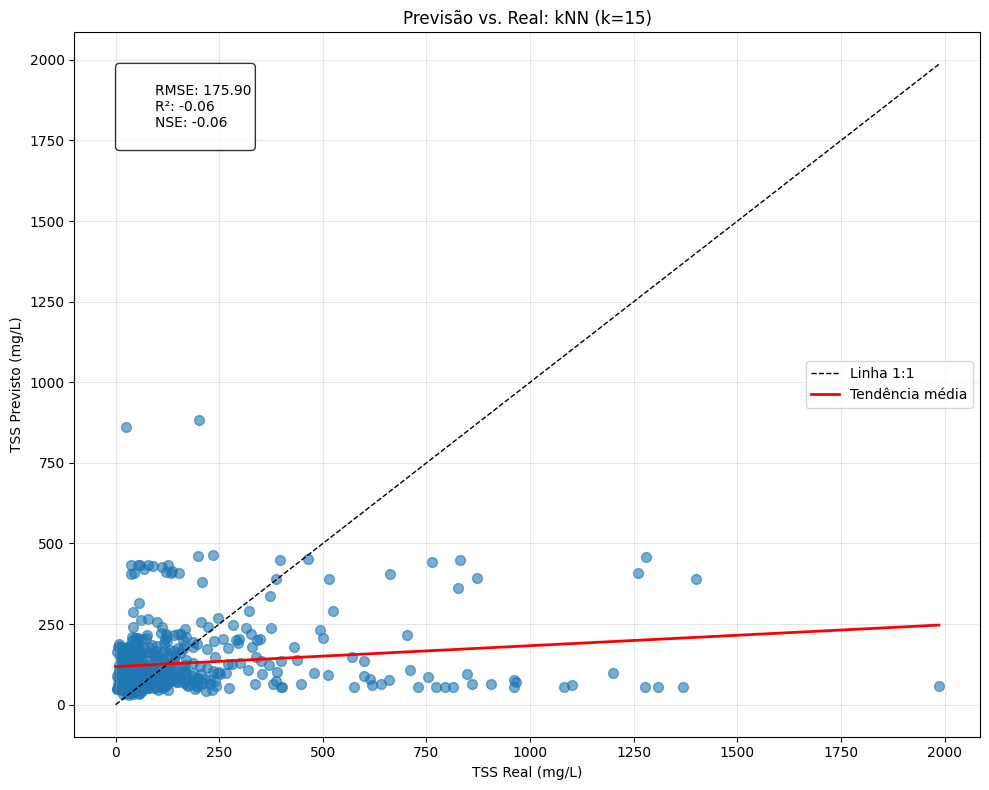

In [11]:
cv_folds = 5
estimator = Pipeline([('knn', KNeighborsRegressor())])
max_k = ceil(filtered_features.shape[0] * (cv_folds - 1) / cv_folds)
param_grid = {
    'knn__n_neighbors': range(1, max_k),
    'knn__weights': ['distance']
}
folds = KFold(n_splits=cv_folds, shuffle=True, random_state=SEED)

gs_features = GridSearchCV(
    estimator,
    param_grid,
    cv=folds,
    scoring = 'neg_root_mean_squared_error',
    n_jobs = -1
)

plot_regression_results(
    gs_features.fit(filtered_features, filtered_targets),
    filtered_features,
    filtered_targets,
    f'kNN (k={gs_features.best_params_['knn__n_neighbors']})'
)

## Aplicar sobre as componentes do PCA

Em seguida aplicamos o kNN usando as componentes principais como valores de entrada. Tem-se que fazê-lo desta forma não acarreta em significativa alteração do desempenho, mas apresenta desempenho comparável com um número reduzido do total de componentes disponíveis: apenas 5 componentes foram utilizadas na solução de melhor desempenho.

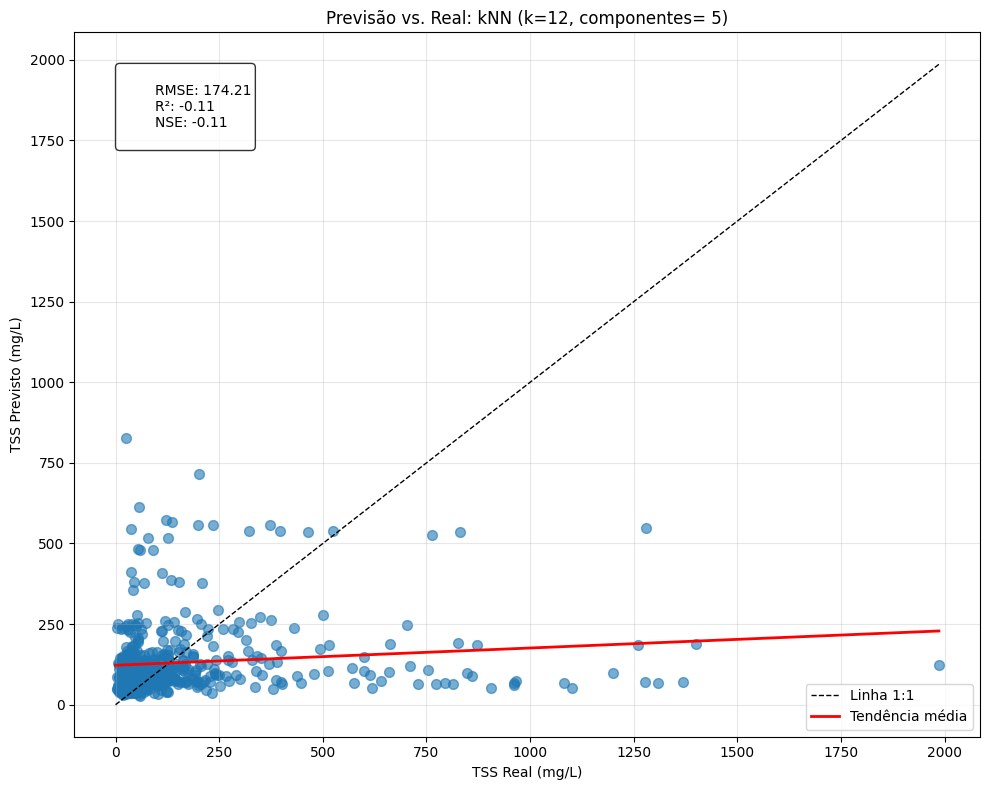

In [12]:
# Set initial values for rmse, gs and the number of components
best_gs = None
best_components = 0
best_neg_rmse = -np.inf

for i in range(1, pca_scores.shape[1]):
    gs = GridSearchCV(
        estimator,
        param_grid,
        cv=KFold(n_splits=cv_folds, shuffle=True, random_state=SEED),
        scoring = 'neg_root_mean_squared_error',
        n_jobs=-1,
    )
    gs.fit(filtered_pca[:,:i], filtered_targets)

    # Update rmse and gs values if a better result is achieved
    if gs.best_score_ > best_neg_rmse:
        best_neg_rmse = gs.best_score_
        best_gs = gs
        best_components = i

plot_regression_results(
    gs,
    filtered_pca[:, :best_components],
    filtered_targets,
    f'kNN (k={gs.best_params_['knn__n_neighbors']}, componentes= {best_components})'
)

## Separação em clusters

Separamos as amostras em agrupamentos (_clusters_) fazendo uso da técnica k-means, demosntrada em aula, e a métrica [sihlouette score](https://en.wikipedia.org/wiki/Silhouette_(clustering)). Esta última indica a adequação da formação dos agrupamentos espacialmente, atribuindo-os um valor entre -1 e 1, onde 1 é o valor ótimo. Clusters com um valor igual ou maior 0.7 são considerados bons, enquanto com valores menores mas acima de 0.5 são considerados razoáveis. Dado o número limitado de amostras, testamos configurações de cluster com 2 a 10 separações, e escolhemos o número de clusters que obteve a melhor pontuação.

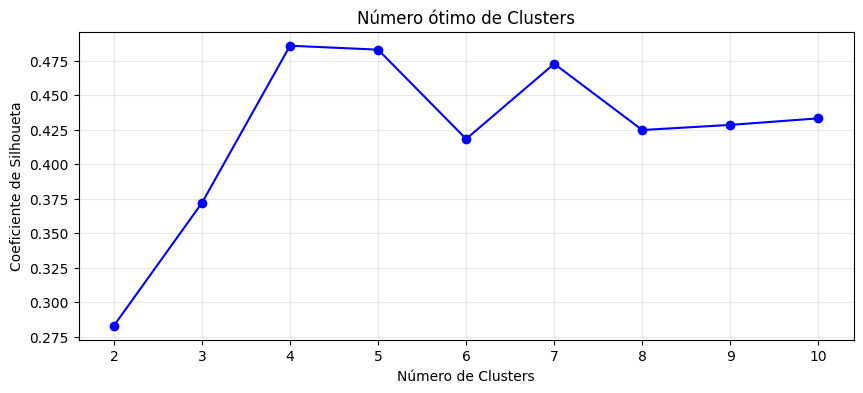

In [13]:
# Use the first n principal components for clustering
X_cluster = filtered_pca[:, :best_components]

# Determine optinal number of clusters
silhouette_scores = []
max_score = 0
optimal_k = -1
k_range = range(2, 11)
for k in k_range:
    kmeans = KMeans(n_clusters = k, random_state=SEED)
    cluster_labels = kmeans.fit_predict(X_cluster)
    score = silhouette_score(X_cluster, cluster_labels)
    silhouette_scores.append(score)
    if score > max_score:
        max_score = score
        optimal_k = k

# Plot silhouette scores to choose optimal k
plt.figure(figsize=(10, 4))
plt.plot(k_range, silhouette_scores, 'bo-')
plt.xlabel('Número de Clusters')
plt.ylabel('Coeficiente de Silhoueta')
plt.title('Número ótimo de Clusters')
plt.grid(True, alpha=0.3)
plt.show()

In [14]:
# Apply Optimal k based on previous inspections
kmeans = KMeans(n_clusters= optimal_k, random_state=SEED, n_init=10)
cluster_labels = kmeans.fit_predict(X_cluster)

In [15]:
# Create interactive 3D plot with clusters
fig = Figure()

# Color by cluster
for cluster_id in np.unique(cluster_labels):
    mask = cluster_labels == cluster_id
    count = mask.sum()
    
    fig.add_trace(Scatter3d(
        x=filtered_pca[:, 0][mask],
        y=filtered_pca[:, 1][mask],
        z=filtered_pca[:, 2][mask],
        mode='markers',
        marker=dict(
            size=5,
            opacity=0.7
        ),
        name=f'Cluster {cluster_id} (n={count})',  # ← Add count to legend
        text=[f'TSS: {val:.1f} mg/L' for val in filtered_targets.iloc[mask]]
    ))

fig.update_layout(
    title='3D PCA com os Clusters identificados',
    scene=dict(
        xaxis_title='PC1',
        yaxis_title='PC2',
        zaxis_title='PC3'
    ),
    width=900,
    height=700
)

fig.show()

## Aplicação do kNN em clusters distintos

In [16]:
# Store results for each cluster
cluster_results = {}
all_predictions = np.zeros_like(filtered_targets, dtype=float)

# Perform cross-validation cluster by cluster
for cluster_id in sorted(np.unique(cluster_labels)):
    print(f"\n=== Processando Cluster {cluster_id} ===")
    
    # Get data for this cluster only
    mask = cluster_labels == cluster_id
    X_cluster = filtered_pca[:,:best_components][mask]
    y_cluster = filtered_targets[mask]
    n_cluster_samples = len(X_cluster)
    
    if n_cluster_samples < cv_folds:
        print(f"  Pulando cluster {cluster_id}: número de amostras ({n_cluster_samples}) insuficiente para {cv_folds}-fold CV")
        continue
    
    # Calculate cluster-specific max_k
    cluster_max_k = ceil(n_cluster_samples * (cv_folds - 1) / cv_folds)
    param_grid = {
        'knn__n_neighbors': range(1, cluster_max_k),
        'knn__weights': ['distance']
    }
    
    print(f"  Tamanho do cluster: {n_cluster_samples}, k máximo: {cluster_max_k}")
    
    # Grid search for this cluster
    gs = GridSearchCV(
        estimator,
        param_grid,
        cv=folds,
        scoring = 'neg_root_mean_squared_error',
        n_jobs=-1,
    )
    gs.fit(X_cluster, y_cluster)
    
    # Cross-validation predictions for this cluster
    cv_predictions_cluster = cross_val_predict(
        gs.best_estimator_,
        X_cluster,
        y_cluster,
        cv=folds
    )
    
    # Store results
    cluster_results[cluster_id] = {
        'X': X_cluster,
        'y_true': y_cluster,
        'y_pred': cv_predictions_cluster,
        'best_k': gs.best_params_['knn__n_neighbors'],
        'best_model': gs.best_estimator_,
        'rmse': -gs.best_score_,
        'r2': R2(y_cluster, cv_predictions_cluster),
        'nse': NSE(y_cluster, cv_predictions_cluster),
        'n_samples': n_cluster_samples,
        'max_k': cluster_max_k
    }
    
    # Store predictions in the full array
    all_predictions[mask] = cv_predictions_cluster
    print(f"  k ótimo: {gs.best_params_['knn__n_neighbors']}, "
          f"RMSE: {-gs.best_score_:.2f}, R²: {R2(y_cluster, cv_predictions_cluster):.3f}")

# Calculate overall metrics
overall_rmse = RMSE(filtered_targets, all_predictions)
overall_r2 = R2(filtered_targets, all_predictions)
overall_nse = NSE(filtered_targets, all_predictions)

print(f"\n=== Resultado agregado ===")
print(f"RMSE: {overall_rmse:.2f} mg/L")
print(f"R²: {overall_r2:.3f}")
print(f"NSE: {overall_nse:.3f}")


=== Processando Cluster 0 ===
  Tamanho do cluster: 211, k máximo: 169
  k ótimo: 7, RMSE: 136.32, R²: 0.494

=== Processando Cluster 1 ===
  Tamanho do cluster: 121, k máximo: 97
  k ótimo: 19, RMSE: 107.10, R²: 0.135

=== Processando Cluster 2 ===
  Tamanho do cluster: 76, k máximo: 61
  k ótimo: 60, RMSE: 133.69, R²: -0.150

=== Processando Cluster 3 ===
  Tamanho do cluster: 122, k máximo: 98
  k ótimo: 9, RMSE: 266.54, R²: 0.434

=== Resultado agregado ===
RMSE: 176.83 mg/L
R²: 0.455
NSE: 0.455


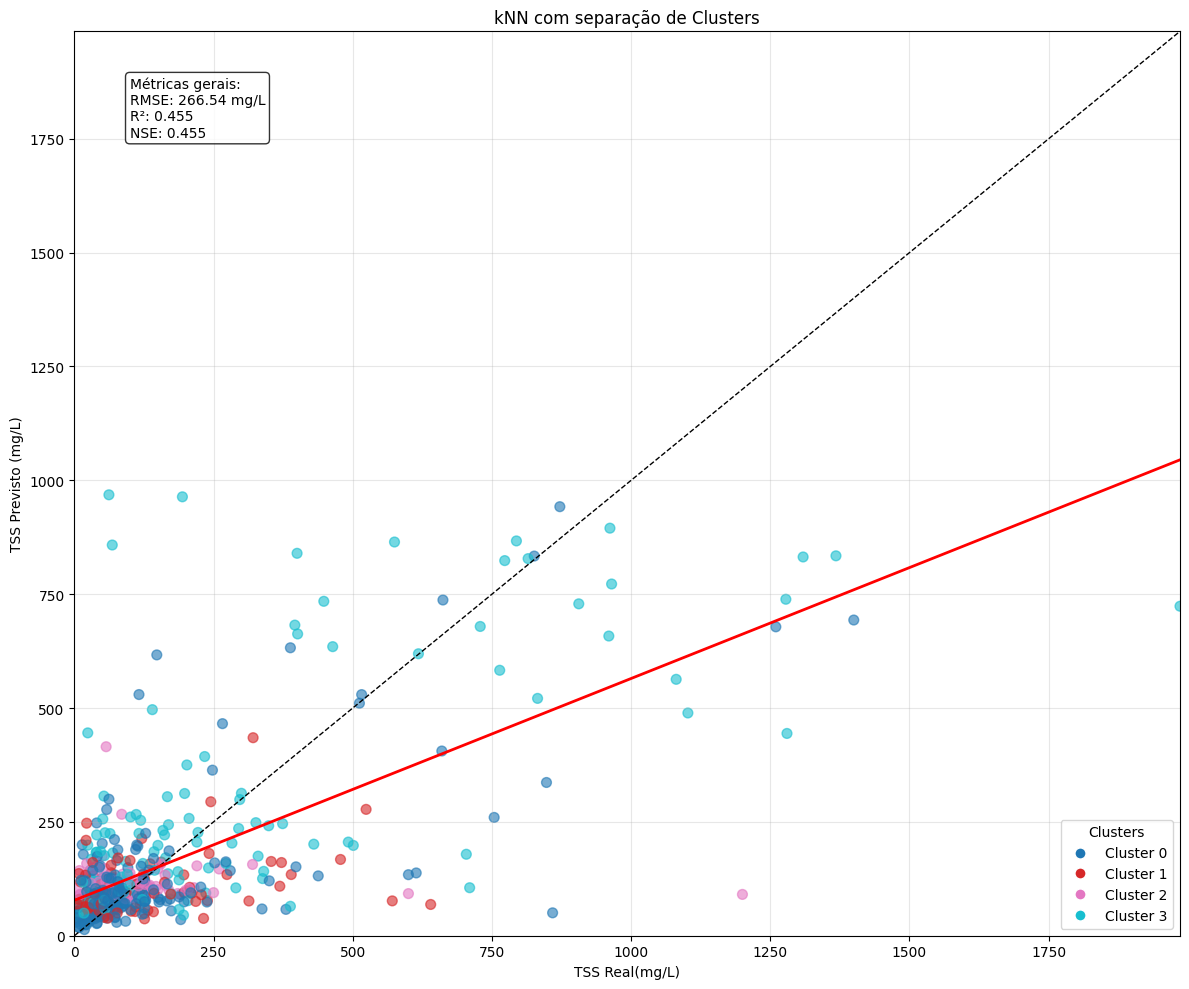

In [17]:
# Merging PCA data and label data into a dataframe
pca_clusters = pd.DataFrame(
    filtered_pca, columns=[f'PC{i+1}' for i in range(filtered_pca.shape[1])]
)
pca_clusters['cluster'] = cluster_labels

# Create one comprehensive plot colored by cluster
plt.figure(figsize=(12, 10))

# Plot all points colored by cluster
scatter = plt.scatter(filtered_targets, all_predictions, c=pca_clusters['cluster'], 
                     cmap='tab10', alpha=0.6, s=50)

# 1:1 line
max_val = max(filtered_targets.max(), all_predictions.max())
plt.plot([0, max_val], [0, max_val], 'k--', linewidth=1, label='Linha 1:1')

# Overall regression line
lr_overall = LinearRegression()
lr_overall.fit(filtered_targets.values.reshape(-1, 1), all_predictions)
x_line = np.linspace(0, max_val, 100)
y_line = lr_overall.predict(x_line.reshape(-1, 1))
plt.plot(x_line, y_line, 'r-', linewidth=2, label='Tendência média')

plt.xlim(0, max_val)
plt.ylim(0, max_val)
plt.xlabel('TSS Real(mg/L)')
plt.ylabel('TSS Previsto (mg/L)')
plt.title(f'kNN com separação de Clusters')
plt.grid(True, alpha=0.3)

unique_clusters = sorted(pca_clusters['cluster'].unique())
norm = plt.Normalize(vmin=min(unique_clusters), vmax=max(unique_clusters))
cmap = plt.cm.tab10

legend_elements = [Line2D([0], [0], marker='o', color='w', 
                          markerfacecolor=cmap(norm(cluster_id)), 
                          markersize=8, label=f'Cluster {cluster_id}')
                  for cluster_id in unique_clusters]

plt.legend(handles=legend_elements, title='Clusters')

# Add statistics textbox
stats_text = f'Métricas gerais:\nRMSE: {-gs.best_score_:.2f} mg/L\nR²: {overall_r2:.3f}\nNSE: {overall_nse:.3f}'
plt.text(0.05, 0.95, stats_text, transform=plt.gca().transAxes, 
         verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()

## Conclusão

Temos que a separação de clusters impactou positivamente o desempenho da técnica kNN. Ainda que o algoritmo estivesse corrigido com pesos para reduzir a importância de amostras muito ditantes no cálculo da predição, remover amostras muito distantes da análise pelo uso de agrupamentos nos deu resultados com melhores estimativas, demonstrando a presença de ruído nas análises anteriores.